In [ ]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import re
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

## DATA PREP

In [ ]:
df = pd.read_csv('../data/newport_raw.csv', dtype=str)

In [ ]:
df.columns = df.columns.str.lower()
visits_cols = [f"visits_h{x}" for x in range(168)]

df[visits_cols] = df[visits_cols].apply(
  pd.to_numeric, 
  errors='coerce'
)

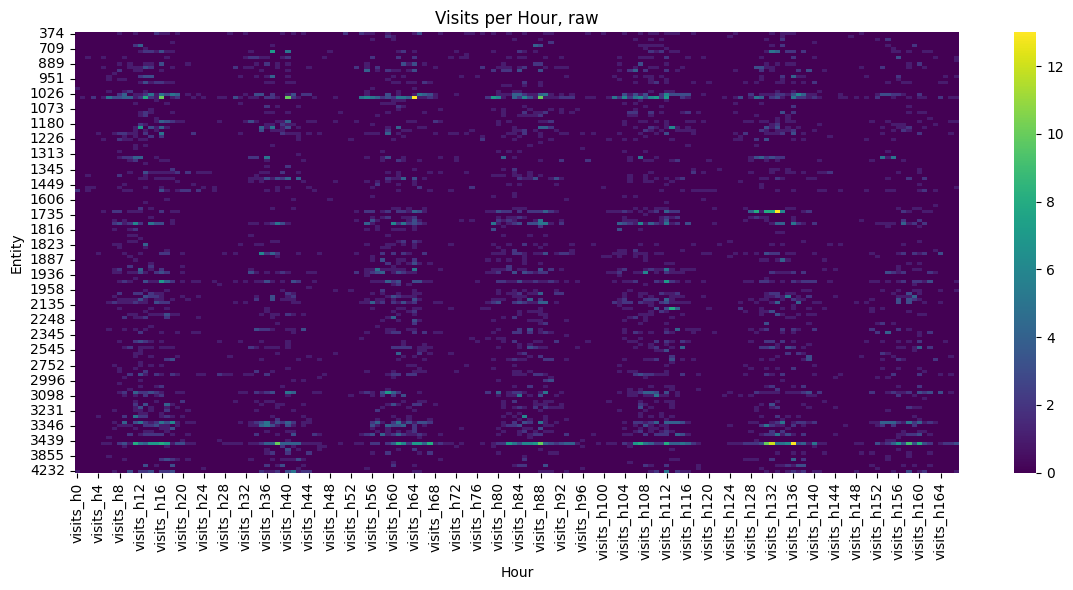

In [ ]:
# Extract just the nonmissing visits data
visits_data = df[visits_cols].astype(float).dropna() 

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(visits_data, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour, raw")
plt.tight_layout()
plt.show()


In [ ]:
dat = df.dropna(subset=visits_cols)    #training set

dat = dat.melt(
  id_vars=['prim_occ', 'sqmeters', 'build_id'], 
  value_vars=visits_cols, 
  var_name='hour_of_week', 
  value_name='visits'
)
dat['hour_of_week'] = dat['hour_of_week'].str.extract(r'(\d+)').astype(int)
dat['sqmeters'] = pd.to_numeric(dat['sqmeters'], errors='coerce')
dat['hour_d'] = dat['hour_of_week'] % 24 # 0-23
dat['sin_hod'] = np.sin(2*np.pi*dat['hour_d']/24)
dat['cos_hod'] = np.cos(2*np.pi*dat['hour_d']/24)


dat['day_w'] = dat['hour_of_week'] // 24 # 0-6
dat['sin_dow'] = np.sin(2*np.pi*dat['day_w']/7)
dat['cos_dow'] = np.cos(2*np.pi*dat['day_w']/7)


dat['sqmeters_scaled'] = dat['sqmeters'] / dat['sqmeters'].max()
dat['log_sqmeters'] = np.log(dat['sqmeters'])

dat['sq_q'] = pd.qcut(dat['sqmeters_scaled'], 4, labels=False)

dat['x_prim_occ'] = dat['prim_occ'].astype('category').cat.codes



In [ ]:
# split into train and test set, random building x time points

# from sklearn.model_selection import train_test_split
# tr, test, y_tr, y_test = train_test_split(
#     dat.drop('visits', axis = 1), dat['visits'], test_size=0.2, random_state=42)

# Hold out 10% of buildings
builds = dat['build_id'].unique()
rng = np.random.default_rng()
builds = rng.choice(builds, len(builds)//10)

mask = dat['build_id'].isin(builds)
tr = dat[~mask].drop('visits', axis = 1)
test = dat[mask].drop('visits', axis = 1)

y_tr = dat[~mask]['visits']
y_test = dat[mask]['visits']



C:\Users\ngoc0\AppData\Local\Temp\ipykernel_23536\4030594158.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


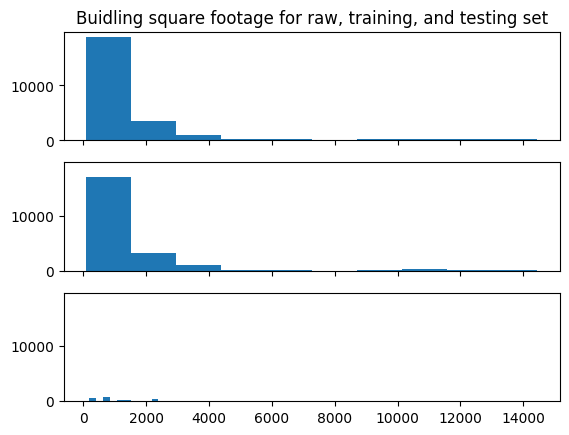

In [ ]:
fig, axes = plt.subplots(3, sharex = True, sharey = True)
axes.flatten()[0].hist(dat['sqmeters'])
axes.flatten()[1].hist(tr['sqmeters'])
axes.flatten()[2].hist(test['sqmeters'])
axes.flatten()[0].set_title('Buidling square footage for raw, training, and testing set')
fig.show()

In [ ]:
x_sin_hod = torch.tensor(tr['sin_hod'].values, dtype=torch.float32).unsqueeze(1)
x_cos_hod = torch.tensor(tr['cos_hod'].values, dtype=torch.float32).unsqueeze(1)
x_area = torch.tensor(tr['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1)
x_sin_dow = torch.tensor(tr['sin_dow'].values, dtype=torch.float32).unsqueeze(1)
x_cos_dow = torch.tensor(tr['cos_dow'].values, dtype=torch.float32).unsqueeze(1)
x_type = torch.tensor(tr['x_prim_occ'].values, dtype=torch.long)

device = torch.device('gpu' if torch.cuda.is_available() else 'cpu')
y = torch.tensor(y_tr.values, dtype=torch.float32).unsqueeze(1)

x_sin_hod = x_sin_hod.to(device)
x_cos_hod = x_cos_hod.to(device)
x_area = x_area.to(device)
x_sin_dow  = x_sin_dow.to(device)
x_cos_dow = x_cos_dow.to(device)
y      = y.to(device)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        input_size = 5 + 5
        hidden_size = 32
        output_size = 1
        
        self.type_emb = nn.Embedding(13, 5)
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type):
        x_type_emb = self.type_emb(x_type)
        x = torch.cat([x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type_emb], dim=1)
        return self.net(x)

In [ ]:
loss_fn = nn.PoissonNLLLoss(log_input=True)

In [ ]:
model = Net().to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
n_learners = 4

In [ ]:
import torch
import torch.nn as nn

num_epochs = 1000
boost_lr = 0.1

learners = []

for m in range(n_learners):

    print(f"\nTraining learner {m+1}/{n_learners}")

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Freeze previous learners
    for mdl in learners:
        mdl.eval()
        for p in mdl.parameters():
            p.requires_grad_(False)

    # Compute previous ensemble log-rate ONCE
    with torch.no_grad():
        if learners:
            prev_log_rate = sum(
                boost_lr
                * mdl(
                    x_sin_hod,
                    x_cos_hod,
                    x_area,
                    x_sin_dow,
                    x_cos_dow,
                    x_type,
                )
                for mdl in learners
            )
        else:
            prev_log_rate = torch.zeros_like(y)

    for epoch in range(num_epochs):

        model.train()
        optimizer.zero_grad()
        
        current_log_rate = model(
            x_sin_hod,
            x_cos_hod,
            x_area,
            x_sin_dow,
            x_cos_dow,
            x_type,
        )

        if not learners:
            ensemble_log_rate = current_log_rate
        else:
            ensemble_log_rate = prev_log_rate + boost_lr * current_log_rate
            
        ensemble_log_rate = (
            prev_log_rate
            + boost_lr * current_log_rate
        )

        loss = loss_fn(ensemble_log_rate, y)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

    model.eval()
    learners.append(model)


Training learner 1/4
Epoch    0 | Loss = 1.014595
Epoch   50 | Loss = 0.732223
Epoch  100 | Loss = 0.500390
Epoch  150 | Loss = 0.472128
Epoch  200 | Loss = 0.445304
Epoch  250 | Loss = 0.415437
Epoch  300 | Loss = 0.393106
Epoch  350 | Loss = 0.384541
Epoch  400 | Loss = 0.379968
Epoch  450 | Loss = 0.375996
Epoch  500 | Loss = 0.372455
Epoch  550 | Loss = 0.368865
Epoch  600 | Loss = 0.365094
Epoch  650 | Loss = 0.360931
Epoch  700 | Loss = 0.357135
Epoch  750 | Loss = 0.353242
Epoch  800 | Loss = 0.349505
Epoch  850 | Loss = 0.345082
Epoch  900 | Loss = 0.340946
Epoch  950 | Loss = 0.336663

Training learner 2/4
Epoch    0 | Loss = 0.333215
Epoch   50 | Loss = 0.333053
Epoch  100 | Loss = 0.332386
Epoch  150 | Loss = 0.330829
Epoch  200 | Loss = 0.328001
Epoch  250 | Loss = 0.323862
Epoch  300 | Loss = 0.318277
Epoch  350 | Loss = 0.312520
Epoch  400 | Loss = 0.307162
Epoch  450 | Loss = 0.303519
Epoch  500 | Loss = 0.299987
Epoch  550 | Loss = 0.297270
Epoch  600 | Loss = 0.294360

In [ ]:
model.eval()
device = torch.device('gpu' if torch.cuda.is_available() else 'cpu')

x_sin_hod = torch.tensor(test['sin_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
x_cos_hod = torch.tensor(test['cos_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
x_area = torch.tensor(test['log_sqmeters'].values, dtype=torch.float32).unsqueeze(1).to(device)
x_sin_dow = torch.tensor(test['sin_dow'].values, dtype=torch.float32).unsqueeze(1).to(device)
x_cos_dow = torch.tensor(test['cos_dow'].values, dtype=torch.float32).unsqueeze(1).to(device)
x_type = torch.tensor(test['x_prim_occ'].values, dtype=torch.long).to(device)

y = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)


with torch.no_grad():

    ensemble_log_rate = sum(
        boost_lr
        * mdl(
            x_sin_hod,
            x_cos_hod,
            x_area,
            x_sin_dow,
            x_cos_dow,
            x_type,
        )
        for mdl in learners
    )

    pred = torch.exp(ensemble_log_rate).cpu().squeeze()
    obs = y.detach().cpu().squeeze().numpy()

df_pred = pd.DataFrame({
    'build_id': test['build_id'],
    'type':    test['prim_occ'],
    'day_w':     test['day_w'],        
    'hour_d':    test['hour_d'],           
    'sq_q':    test['sq_q'],
    'pred':    pred,
    'obs':     obs
})

df_grp = (
    df_pred
    .groupby(['type', 'day_w','hour_d'], observed=True)[['pred','obs']]
    .mean()
    .reset_index()
)


known_categories = set(tr['prim_occ'].unique())

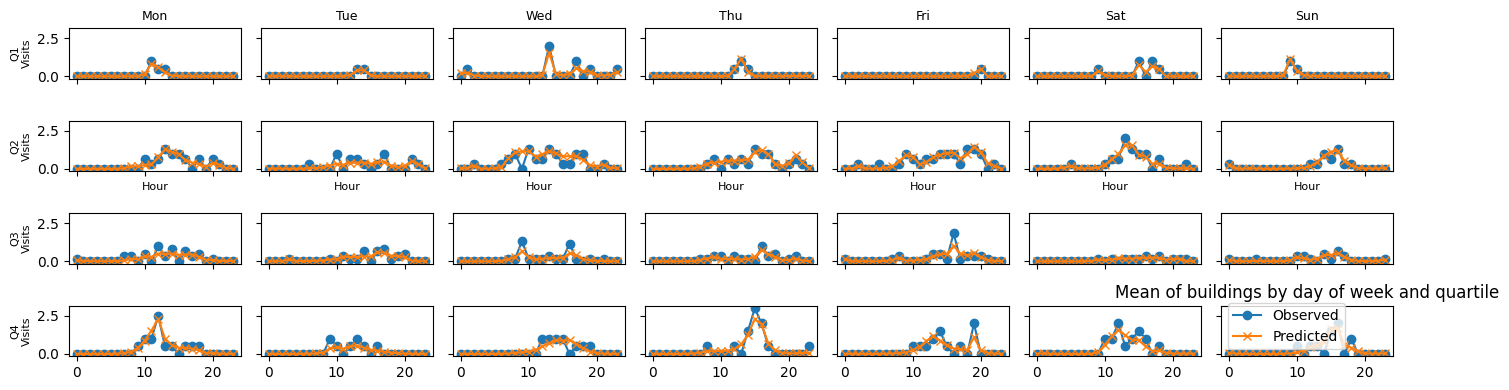

In [ ]:
# Parameters
quartiles = [0,1,2,3]  # Q1 and Q4
dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
days = [0,1,2,3,4,5,6]

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(4, 7, figsize=(14, 4), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(quartiles):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (
            (df_pred['day_w'] == day) &
            (df_pred['sq_q'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour_d', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'], marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel(f"Q{q+1}\nVisits", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(dow[day], fontsize=9)

plt.title('Mean of buildings by day of week and quartile')
plt.tight_layout()
plt.legend()
plt.show()



C:\Users\ngoc0\AppData\Local\Temp\ipykernel_23536\1966386296.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  build_preds['hour_w'] = build_preds['day_w']*24 + build_preds['hour_d']


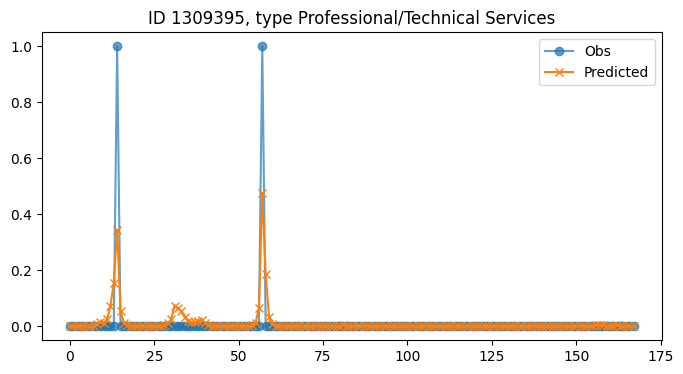

In [ ]:
test_builds = df_pred['build_id'].unique()
rand = np.random.default_rng()

build = rand.choice(test_builds)
build_preds = df_pred[df_pred['build_id'] == build]
build_preds['hour_w'] = build_preds['day_w']*24 + build_preds['hour_d']

fig, ax = plt.subplots(figsize = (8,4))

ax.plot(build_preds['hour_w'], build_preds['obs'], marker='o', alpha = 0.7,  label='Obs')
ax.plot(build_preds['hour_w'], build_preds['pred'], marker='x',  label='Predicted')

plt.title(f"ID {build_preds['build_id'].iloc[0]}, type {build_preds['type'].iloc[0]}")
plt.legend()


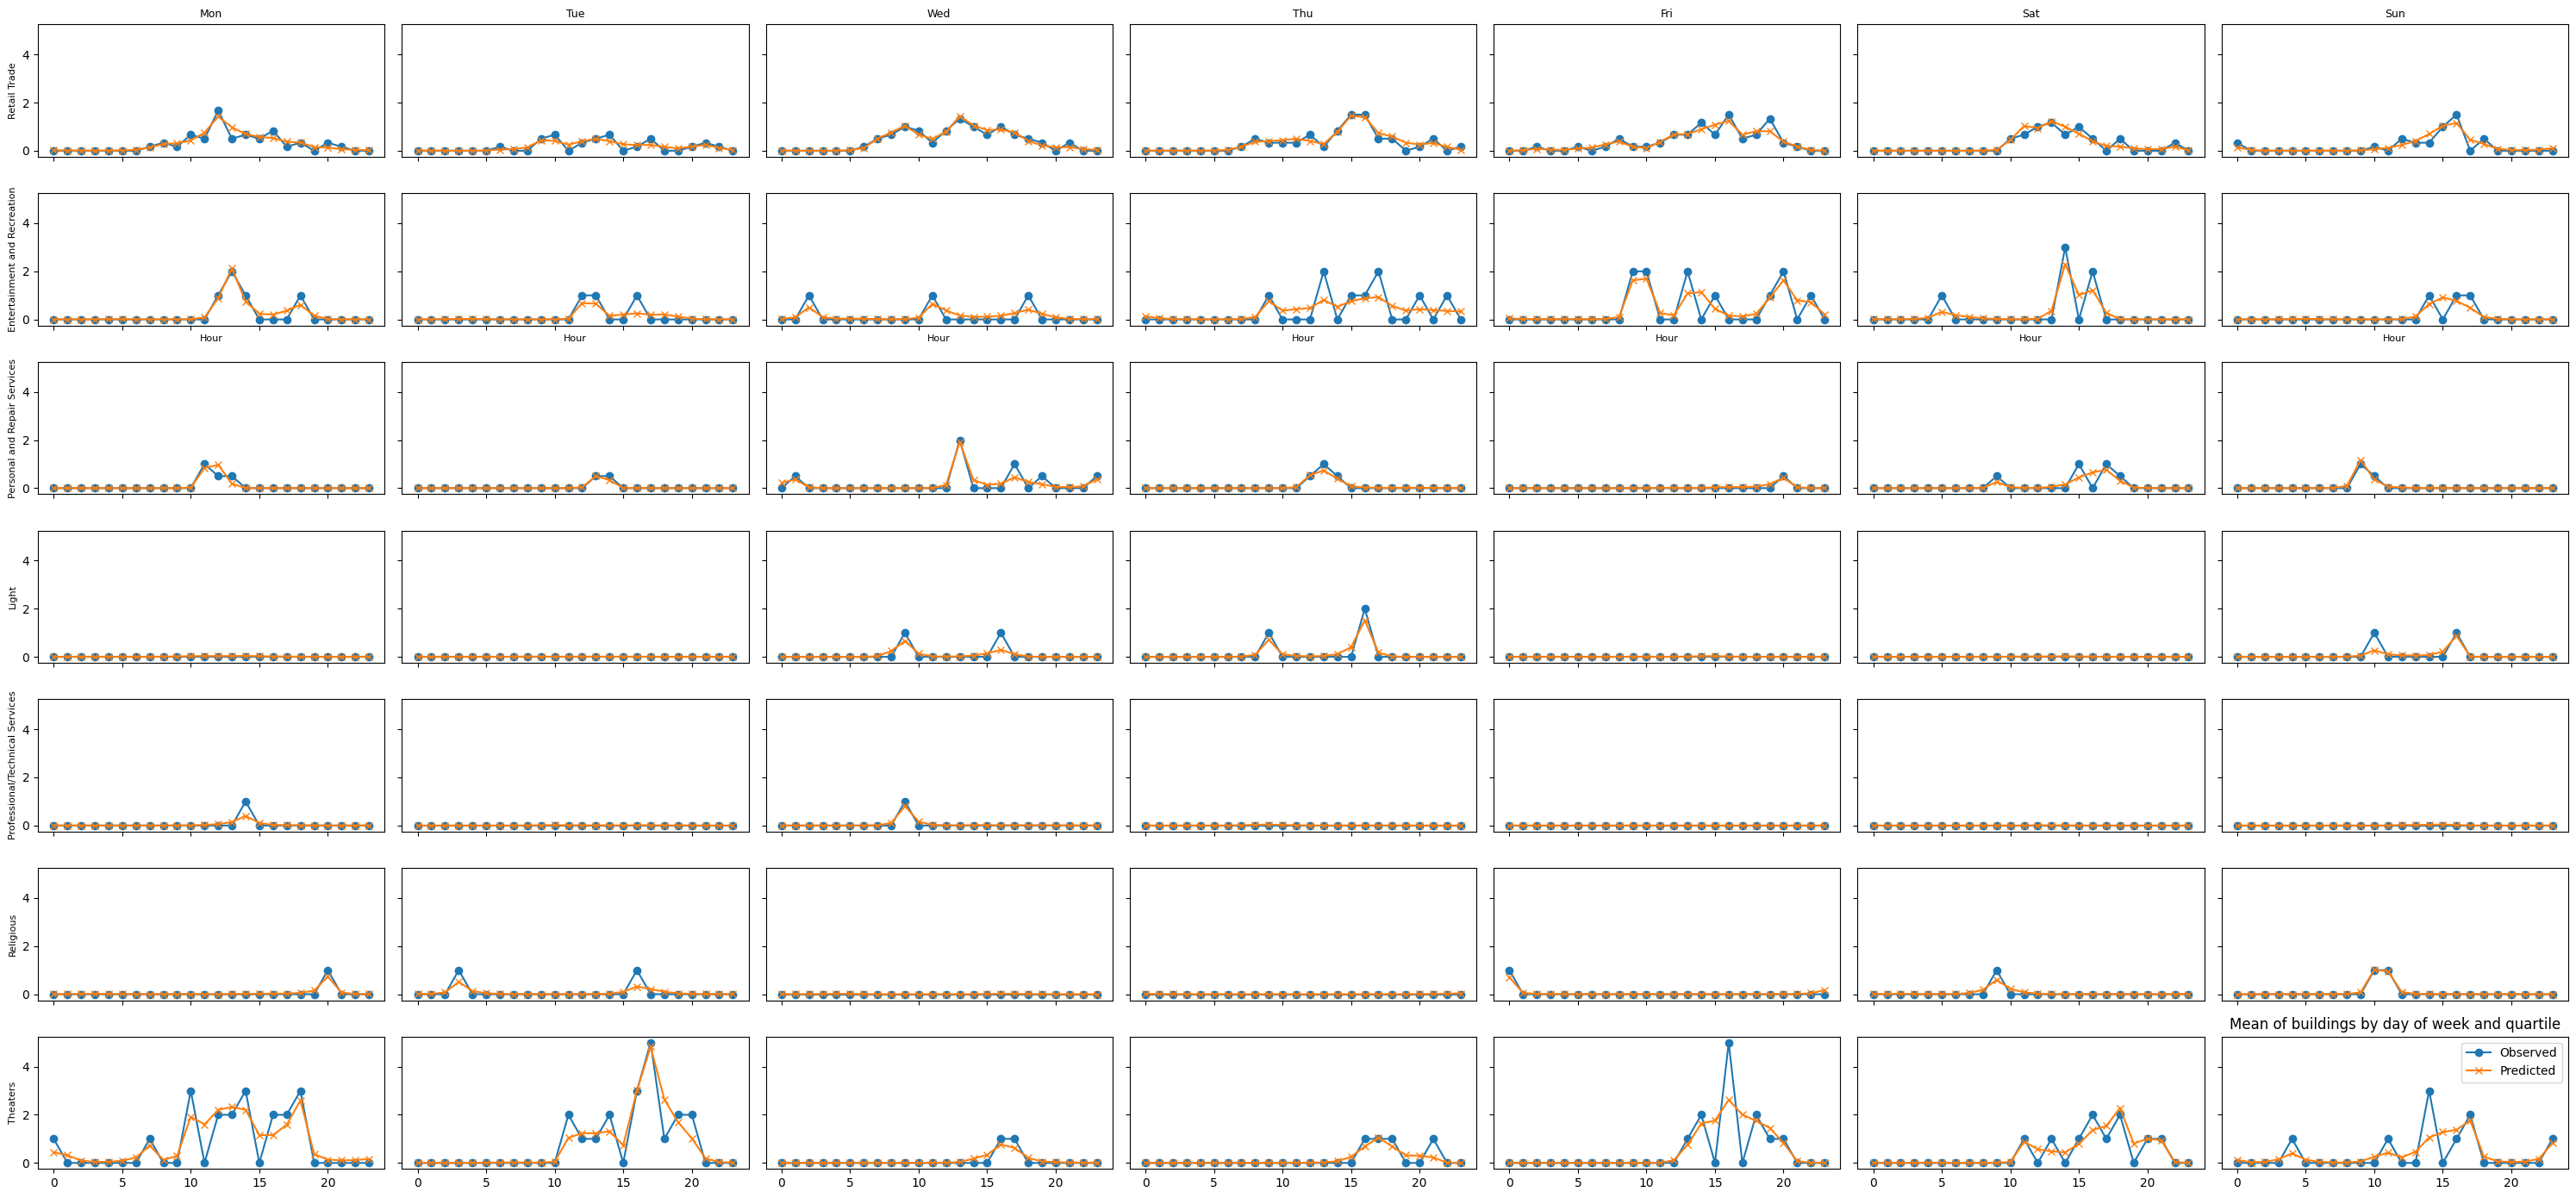

In [ ]:
# Parameters
categories = df_pred['type'].unique()
n_cats = len(categories)
dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
days = [0,1,2,3,4,5,6]

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(n_cats, 7, figsize=(30, 14), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(categories):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (
            (df_pred['day_w'] == day) &
            (df_pred['type'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour_d', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'], marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel(f"{q}", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(dow[day], fontsize=9)

plt.title('Mean of buildings by day of week and quartile')
plt.tight_layout()
plt.legend()
plt.show()



Text(0.5, 1.0, 'pred vs obs')

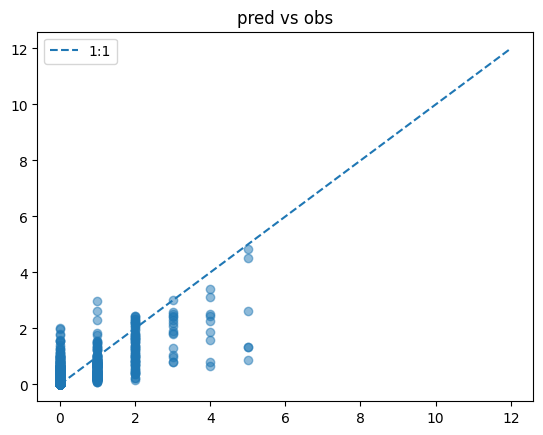

In [ ]:
plt.scatter(df_pred['obs'], df_pred['pred'],
            alpha=0.5)
plt.plot([0,12], [0, 12], linestyle = '--', label = '1:1')
plt.legend()
plt.title("pred vs obs")

In [ ]:

df_pred['hour_w'] = df_pred['day_w'] * 24 + df_pred['hour_d']
df_pred['simulated'] = np.random.poisson(df_pred['pred'])
pred_wide = df_pred.pivot(index = 'build_id', columns = 'hour_w', values = 'simulated')

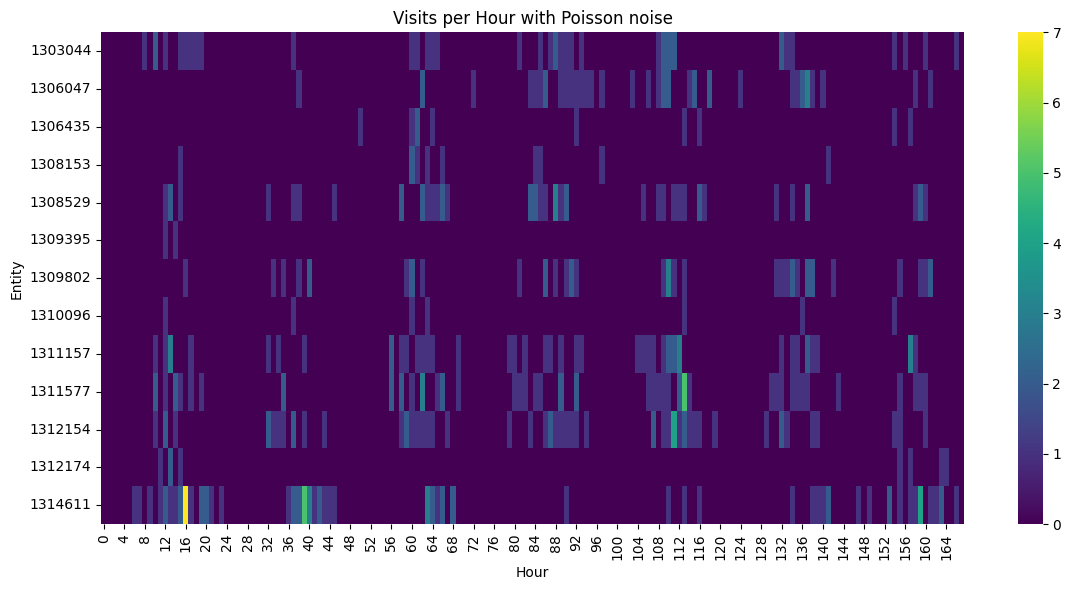

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour with Poisson noise")
plt.tight_layout()
plt.show()

In [ ]:
nonres = df[df['occ_cls']!= 'Residential'][pd.isna(df['sg_match'])]

nonres = nonres.melt(
  id_vars=['prim_occ', 'sqmeters', 'build_id'], 
  value_vars=visits_cols, 
  var_name='hour_of_week', 
  value_name='visits'
)

nonres['prim_occ'] = nonres['prim_occ'].where(
    nonres['prim_occ'].isin(known_categories),
    'Unclassified'
)

nonres['hour_of_week'] = nonres['hour_of_week'].str.extract(r'(\d+)').astype(int)
nonres['hour_d'] = nonres['hour_of_week'] % 24 # 0-23
nonres['sin_hod'] = np.sin(2*np.pi*nonres['hour_d']/24)
nonres['cos_hod'] = np.cos(2*np.pi*nonres['hour_d']/24)


nonres['day_w'] = nonres['hour_of_week'] // 24 # 0-6
nonres['sin_dow'] = np.sin(2*np.pi*nonres['day_w']/7)
nonres['cos_dow'] = np.cos(2*np.pi*nonres['day_w']/7)

nonres['sqmeters'] = pd.to_numeric(nonres['sqmeters'], errors='coerce')
nonres['sqmeters_scaled'] = nonres['sqmeters'] / nonres['sqmeters'].max()
nonres['log_sqmeters'] = np.log(nonres['sqmeters'])


nonres['x_prim_occ'] = nonres['prim_occ'].astype('category').cat.codes
nonres

C:\Users\ngoc0\AppData\Local\Temp\ipykernel_21108\1271850532.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nonres = df[df['occ_cls']!= 'Residential'][pd.isna(df['sg_match'])]


,prim_occ,sqmeters,build_id,hour_of_week,visits,hour_d,sin_hod,cos_hod,day_w,sin_dow,cos_dow,sqmeters_scaled,x_prim_occ
0,Unclassified,216.731110,1299962,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.040092,12
1,General Services,1100.336500,1300561,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.203543,2
2,General Services,194.563080,1300567,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.035991,2
3,General Services,214.265960,1300598,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.039636,2
4,Unclassified,324.549620,1299480,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.060036,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116755,Unclassified,197.486420,1315314,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.036532,12
116756,Unclassified,51.079002,1315387,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.009449,12
116757,Personal and Repair Services,464.080100,1315389,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.085847,6
116758,Unclassified,188.199250,1315396,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.034814,12


In [ ]:
z_sin_hod = torch.tensor(nonres['sin_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_cos_hod = torch.tensor(nonres['cos_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
# z_area = torch.tensor(nonres['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_area = torch.tensor(nonres['log_sqmeters'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_sin_dow = torch.tensor(nonres['sin_dow'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_cos_dow = torch.tensor(nonres['cos_dow'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_type = torch.tensor(nonres['x_prim_occ'].values, dtype=torch.long).to(device)


In [ ]:
fill = model(z_sin_hod, z_cos_hod, z_area, z_sin_dow, z_cos_dow, z_type).detach().cpu().squeeze().numpy()
df_pred = pd.DataFrame({
    'build_id': nonres['build_id'],
    'type':    nonres['prim_occ'],
    'day_w':     nonres['day_w'],        
    'hour_d':    nonres['hour_d'],     
    'sq' :      nonres['sqmeters'],      
    'pred':    fill
})

df_pred['hour_w'] = df_pred['day_w'] * 24 + df_pred['hour_d']
pred_wide = df_pred.pivot(index = 'build_id', columns = 'hour_w', values = 'pred')

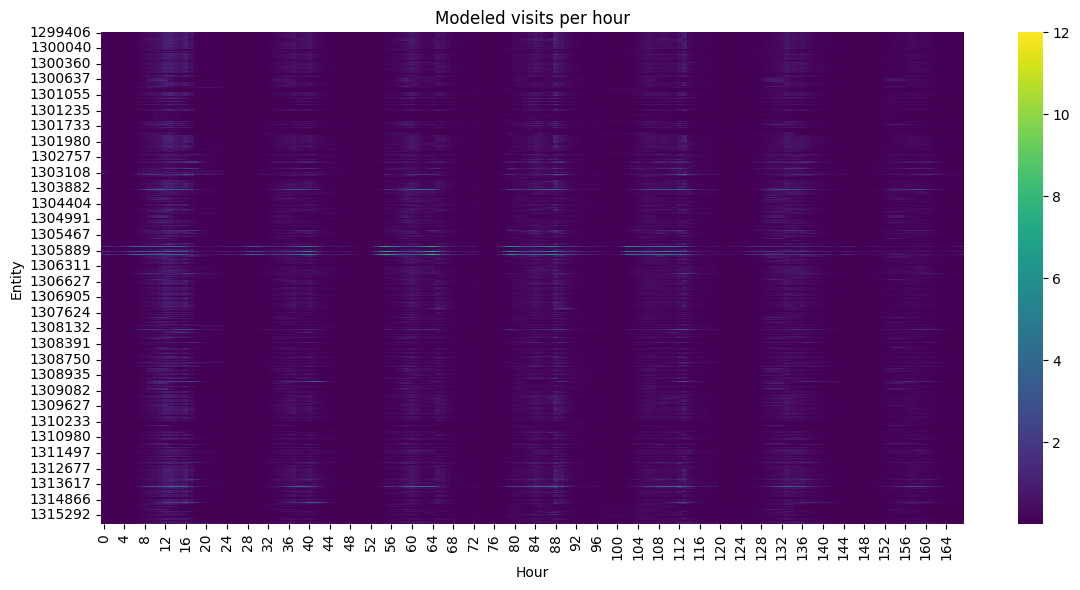

In [ ]:
# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap='viridis', cbar=True, vmax = 12)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Modeled visits per hour")
plt.tight_layout()
plt.show()

In [ ]:
df_pred

,build_id,type,day_w,hour_d,sq,pred,hour_w
0,1299962,Unclassified,0,0,216.731110,0.076730,0
1,1300561,General Services,0,0,1100.336500,0.003760,0
2,1300567,General Services,0,0,194.563080,0.003330,0
3,1300598,General Services,0,0,214.265960,0.003272,0
4,1299480,Unclassified,0,0,324.549620,0.063388,0
...,...,...,...,...,...,...,...
116755,1315314,Unclassified,6,23,197.486420,0.037406,167
116756,1315387,Unclassified,6,23,51.079002,0.040761,167
116757,1315389,Personal and Repair Services,6,23,464.080100,0.000043,167
116758,1315396,Unclassified,6,23,188.199250,0.037610,167


In [ ]:
torch.save(model.state_dict(), 'model_weights.pth')